# 03. Modelo Prophet: entrenamiento y evaluación comparativa

Este notebook aborda el entrenamiento del modelo predictivo principal
del sistema, basado en Prophet. Prophet es una biblioteca de predicción
de series temporales desarrollada por Meta (anteriormente Facebook)
que modela la demanda como la suma de una tendencia no lineal, varias
componentes estacionales (diaria, semanal, anual) y un término de
efectos de festivos, admitiendo además regresores externos.

El objetivo del notebook es:

- Entrenar un modelo Prophet **base** sin regresores externos, como
  punto de partida de referencia.
- Incorporar progresivamente los componentes adicionales (festivos y
  dos variantes de clima) para medir la aportación de cada uno.
- Comparar las distintas configuraciones mediante métricas de error
  (MAE, RMSE, MAPE) evaluadas sobre un conjunto de test independiente.
- Realizar validación cruzada temporal de las configuraciones más prometedoras en dos escenarios operativos
- Guardar el modelo final entrenado para su uso posterior en el panel
  de visualización.

La fuente de datos es el dataset enriquecido generado en el notebook
anterior (`data/processed/dataset_enriquecido.csv`), que contiene la
serie diaria de pedidos junto con las variables contextuales de clima
y festivos.

## 1. Configuración inicial y carga del dataset enriquecido

Se cargan los paquetes necesarios y el dataset enriquecido generado en
el notebook anterior. Este dataset contiene la serie objetivo y todas
las variables contextuales listas para el entrenamiento.

In [250]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from prophet import Prophet
import logging

# Filtramos los warnings non-fatal de Stan durante el muestreo MCMC.
# Estos warnings aparecen durante la fase de warmup cuando Stan explora
# valores extremos para encontrar el espacio óptimo de parámetros, pero
# no afectan al resultado final del muestreo.
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

# Rutas del proyecto
DATA_PROCESSED = Path("../data/processed")

# Carga del dataset enriquecido
dataset = pd.read_csv(
    DATA_PROCESSED / "dataset_enriquecido.csv",
    parse_dates=["fecha"]
)

print(f"Dataset cargado: {len(dataset):,} días × {dataset.shape[1]} columnas")
print(f"Rango temporal: {dataset['fecha'].min().date()} → {dataset['fecha'].max().date()}")
print(f"\nColumnas disponibles:")
for col in dataset.columns:
    print(f"  - {col}")
print(f"\nPrimeras 3 filas:")
dataset.head(3)

Dataset cargado: 1,067 días × 14 columnas
Rango temporal: 2016-09-01 → 2019-08-03

Columnas disponibles:
  - fecha
  - n_pedidos
  - es_festivo
  - festivo_nombre
  - temp_media_dia
  - precipitacion_total_dia
  - viento_medio_dia
  - humedad_media_dia
  - nubosidad_media_dia
  - temp_media_serv
  - precipitacion_total_serv
  - viento_medio_serv
  - humedad_media_serv
  - nubosidad_media_serv

Primeras 3 filas:


,fecha,n_pedidos,es_festivo,festivo_nombre,temp_media_dia,precipitacion_total_dia,viento_medio_dia,humedad_media_dia,nubosidad_media_dia,temp_media_serv,precipitacion_total_serv,viento_medio_serv,humedad_media_serv,nubosidad_media_serv
0,2016-09-01,13,0,NaN,17.42,0.0,9.65,73.38,68.83,19.96,0.0,11.90,59.86,76.0
1,2016-09-02,28,0,NaN,17.14,1.3,14.96,82.58,98.29,18.51,0.0,15.37,81.43,100.0
2,2016-09-03,52,0,NaN,16.83,2.8,17.54,81.54,96.54,17.91,2.6,22.94,85.86,100.0


## 2. Preparación de los datos en formato Prophet

Prophet exige que el DataFrame de entrada tenga una estructura concreta:
- una columna `ds` con las fechas 
- y una columna `y` con los valores de la
serie objetivo. 

Los regresores externos se añaden como columnas
adicionales con el nombre que se desee.

En este apartado se adapta el dataset enriquecido al formato esperado
por Prophet, renombrando la columna `fecha` a `ds` y la columna
`n_pedidos` a `y`. Los regresores se conservan con los nombres
descriptivos actuales para facilitar la interpretación de los
resultados.

In [251]:
# Prophet requiere columnas 'ds' (fecha) y 'y' (valor objetivo)
df_prophet = dataset.rename(columns={
    "fecha": "ds",
    "n_pedidos": "y"
})

# La columna festivo_nombre no la necesita Prophet, pero la conservamos
# para análisis posterior. El indicador es_festivo lo trataremos aparte.
print(f"DataFrame adaptado para Prophet: {len(df_prophet):,} filas × {df_prophet.shape[1]} columnas")
print(f"\nPrimeras 3 filas:")
df_prophet.head(3)

DataFrame adaptado para Prophet: 1,067 filas × 14 columnas

Primeras 3 filas:


,ds,y,es_festivo,festivo_nombre,temp_media_dia,precipitacion_total_dia,viento_medio_dia,humedad_media_dia,nubosidad_media_dia,temp_media_serv,precipitacion_total_serv,viento_medio_serv,humedad_media_serv,nubosidad_media_serv
0,2016-09-01,13,0,NaN,17.42,0.0,9.65,73.38,68.83,19.96,0.0,11.90,59.86,76.0
1,2016-09-02,28,0,NaN,17.14,1.3,14.96,82.58,98.29,18.51,0.0,15.37,81.43,100.0
2,2016-09-03,52,0,NaN,16.83,2.8,17.54,81.54,96.54,17.91,2.6,22.94,85.86,100.0


## 3. División en conjuntos de entrenamiento y test

Para poder evaluar la calidad de las predicciones se divide el dataset en dos conjuntos:

- **Entrenamiento:** el modelo aprende de estos datos. Se corresponde
  con la parte más antigua de la serie.
- **Test:** el modelo no accede a estos datos durante el entrenamiento. Se
  utilizan para comparar las predicciones del modelo con los valores
  reales y calcular las métricas de error.

A diferencia de algoritmos de clasificación, donde la división suele
hacerse aleatoriamente, en series temporales la división debe
respetar el orden cronológico. Entrenar con datos del futuro para
predecir el pasado (data leakage) produciría métricas buenas que no reflejarían el comportamiento real del modelo en
producción.

Se reservan como test los últimos 90 días del dataset (aproximadamente
el 8%). Este periodo equivale al horizonte de predicción habitual en
restauración (un trimestre) y es suficientemente amplio para que las
métricas sean estables, pero no tanto como para reducir
significativamente los datos de entrenamiento.

In [252]:
# Reservamos los últimos 90 días como test (horizonte trimestral)
N_DIAS_TEST = 90

df_train = df_prophet.iloc[:-N_DIAS_TEST].copy()
df_test = df_prophet.iloc[-N_DIAS_TEST:].copy()

print(f"Conjunto de entrenamiento: {len(df_train):,} días")
print(f"  Rango: {df_train['ds'].min().date()} → {df_train['ds'].max().date()}")
print(f"\nConjunto de test: {len(df_test):,} días")
print(f"  Rango: {df_test['ds'].min().date()} → {df_test['ds'].max().date()}")
print(f"\nProporción test / total: {len(df_test) / len(df_prophet) * 100:.1f}%")

Conjunto de entrenamiento: 977 días
  Rango: 2016-09-01 → 2019-05-05

Conjunto de test: 90 días
  Rango: 2019-05-06 → 2019-08-03

Proporción test / total: 8.4%


## 4. Modelo base (solo serie temporal)

Se entrena un primer modelo Prophet utilizando únicamente la
información temporal de la serie de pedidos, sin incorporar ningún
regresor externo ni los festivos. Este modelo representa el
comportamiento que se obtendría aplicando Prophet "directamente" a la
serie, y sirve como referencia para cuantificar la mejora que aportan
las variables contextuales en los modelos posteriores.

La configuración de Prophet se deja en sus valores por defecto en
todos los parámetros estacionales salvo los que se adaptan al
problema. En particular, se desactiva la estacionalidad diaria
(`daily_seasonality=False`) porque los datos son diarios y no hay
información intradía que modelar. Se dejan activas la estacionalidad
semanal (para captar el patrón de fines de semana frente a días
laborables) y la estacionalidad anual (para captar patrones
estacionales a lo largo del año).

In [253]:
# Construcción del modelo base: sin regresores externos ni festivos
modelo_base = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
)

# Prophet solo necesita las columnas ds e y, así que le pasamos solo esas
modelo_base.fit(df_train[["ds", "y"]])

print("Modelo base entrenado correctamente.")

Modelo base entrenado correctamente.


## 5. Predicción del modelo base sobre el conjunto de test

Una vez entrenado el modelo se generan las predicciones para las fechas
del conjunto de test y se comparan con los valores reales.

Prophet realiza las predicciones a través del método `predict`, al que
se le pasa un DataFrame con las fechas (columna `ds`) sobre las que se
quieren obtener resultados. En este caso se utiliza directamente el
conjunto de test, que ya contiene las fechas a predecir.

El método devuelve un DataFrame con la predicción puntual (`yhat`),
los límites del intervalo de confianza (`yhat_lower`, `yhat_upper`) y
las componentes individuales que conforman la predicción (tendencia,
estacionalidades, regresores).

In [254]:
# Generamos las predicciones sobre las fechas del conjunto de test
predicciones_base = modelo_base.predict(df_test[["ds"]])

print(f"Predicciones generadas: {len(predicciones_base):,} días")
print(f"\nColumnas devueltas por Prophet:")
for col in predicciones_base.columns:
    print(f"  - {col}")

print(f"\nPrimeras 3 predicciones (valores clave):")
predicciones_base[["ds", "yhat", "yhat_lower", "yhat_upper"]].head(3)

Predicciones generadas: 90 días

Columnas devueltas por Prophet:
  - ds
  - trend
  - yhat_lower
  - yhat_upper
  - trend_lower
  - trend_upper
  - additive_terms
  - additive_terms_lower
  - additive_terms_upper
  - weekly
  - weekly_lower
  - weekly_upper
  - yearly
  - yearly_lower
  - yearly_upper
  - multiplicative_terms
  - multiplicative_terms_lower
  - multiplicative_terms_upper
  - yhat

Primeras 3 predicciones (valores clave):


,ds,yhat,yhat_lower,yhat_upper
0,2019-05-06,24.420903,13.977897,35.370173
1,2019-05-07,23.856917,13.538258,34.917137
2,2019-05-08,25.806737,14.734598,36.821296


## 6. Métricas de evaluación

Se calculan tres métricas estándar para evaluar la calidad de las
predicciones:

- **MAE (Mean Absolute Error):** el error promedio en valor absoluto,
  expresado en la misma unidad que la variable objetivo (número de
  pedidos).Interpretación: "el modelo se equivoca en media en
  X pedidos por día".
- **RMSE (Root Mean Squared Error):** la raíz del error cuadrático
  medio. Penaliza más los errores grandes que el MAE. Útil cuando
  equivocarse mucho un día es peor que equivocarse poco varios días.
- **MAPE (Mean Absolute Percentage Error):** el error porcentual
  medio. Es adimensional y facilita la comparación entre modelos o
  periodos, aunque puede dar valores extremos si hay días con pocos
  pedidos (división por valores pequeños).

Se definen las funciones de cálculo de forma explícita para tener
control sobre la implementación y poder reutilizarlas en los siguientes
modelos.

In [255]:
def calcular_metricas(y_real: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Calcula las métricas de evaluación estándar para series temporales.
    
    Parámetros
    ----------
    y_real : valores reales observados.
    y_pred : predicciones del modelo.
    
    Devuelve
    --------
    Diccionario con las métricas MAE, RMSE y MAPE.
    """
    error = y_real - y_pred
    mae = np.abs(error).mean()
    rmse = np.sqrt((error ** 2).mean())
    mape = (np.abs(error / y_real) * 100).mean()
    
    return {
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MAPE": round(mape, 2),
    }


# Calculamos las métricas del modelo base
metricas_base = calcular_metricas(
    y_real=df_test["y"].values,
    y_pred=predicciones_base["yhat"].values
)

print("Métricas del modelo base (sin regresores):")
for metrica, valor in metricas_base.items():
    unidad = "pedidos" if metrica in ("MAE", "RMSE") else "%"
    print(f"  {metrica}: {valor} {unidad}")

Métricas del modelo base (sin regresores):
  MAE: 7.63 pedidos
  RMSE: 9.0 pedidos
  MAPE: 28.81 %


In [256]:
def resumen_cv(cv_resultados: pd.DataFrame, nombre: str = "") -> dict:
    """
    Calcula las métricas agregadas sobre los resultados de una
    validación cruzada de Prophet.
    
    Parámetros
    ----------
    cv_resultados : DataFrame devuelto por cross_validation de Prophet.
    nombre : etiqueta del modelo (opcional, para contextualizar).
    
    Devuelve
    --------
    Diccionario con MAE, RMSE, MAPE, número de folds y predicciones.
    """
    metricas = calcular_metricas(
        y_real=cv_resultados["y"].values,
        y_pred=cv_resultados["yhat"].values
    )
    metricas["Nº folds"] = cv_resultados["cutoff"].nunique()
    metricas["Nº predicciones"] = len(cv_resultados)
    return metricas

## 7. Visualización del modelo base

Se representa gráficamente la predicción del modelo base sobre el
conjunto de test frente a los valores reales observados. La gráfica
incluye el intervalo de confianza del 80% devuelto por Prophet,
permitiendo ver no solo el error puntual sino también la incertidumbre
que el modelo asocia a cada predicción.

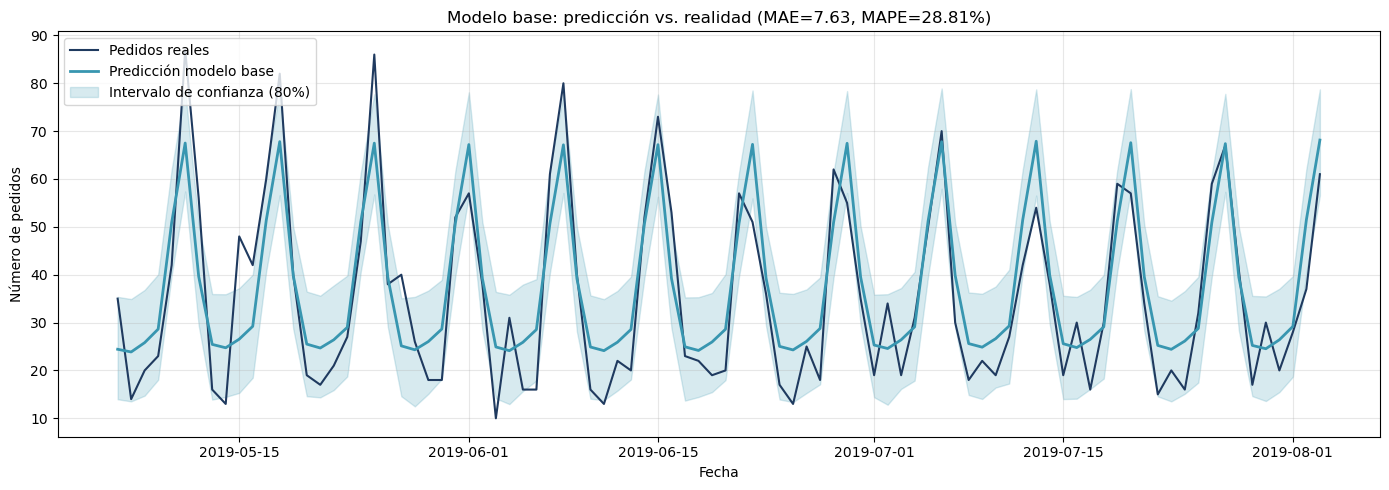

In [257]:
fig, ax = plt.subplots(figsize=(14, 5))

# Valores reales del test
ax.plot(df_test["ds"], df_test["y"], 
        label="Pedidos reales", color="#1f3a5f", linewidth=1.5)

# Predicción del modelo
ax.plot(predicciones_base["ds"], predicciones_base["yhat"],
        label="Predicción modelo base", color="#3896b0", linewidth=2)

# Intervalo de confianza
ax.fill_between(
    predicciones_base["ds"],
    predicciones_base["yhat_lower"],
    predicciones_base["yhat_upper"],
    color="#3896b0", alpha=0.2, label="Intervalo de confianza (80%)"
)

ax.set_title(f"Modelo base: predicción vs. realidad (MAE={metricas_base['MAE']}, MAPE={metricas_base['MAPE']}%)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Número de pedidos")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Modelo con festivos

Se entrena una segunda variante del modelo incorporando los festivos
identificados en el notebook anterior. Prophet admite los festivos a
través del parámetro `holidays` del constructor, que espera un
DataFrame con al menos dos columnas: `ds` (fecha del festivo) y
`holiday` (nombre del festivo, que Prophet usa como identificador).

A diferencia de incorporar los festivos como un simple regresor
binario, este planteamiento permite a Prophet aprender un efecto
específico para cada festivo individual. Así, puede capturar que
Christmas Day tiene un impacto muy distinto al del May Day, lo que
sería imposible si los tratáramos a todos como una variable única.

Se mantiene exactamente la misma configuración que en el modelo base
en el resto de parámetros, de forma que la única diferencia sea la
incorporación de los festivos. Esto permite atribuir cualquier cambio
en las métricas únicamente a su efecto.

In [258]:
# Preparamos el DataFrame de festivos en el formato que Prophet espera
# Prophet necesita columnas 'ds' y 'holiday'
festivos_prophet = dataset[["fecha", "festivo_nombre"]].dropna().copy()
festivos_prophet = festivos_prophet.rename(columns={
    "fecha": "ds",
    "festivo_nombre": "holiday"
})

print(f"Festivos incorporados al modelo: {len(festivos_prophet)}")
print(f"\nPrimeros 5:")
print(festivos_prophet.head().to_string(index=False))

# Construimos el modelo con festivos
modelo_festivos = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=festivos_prophet,
)

modelo_festivos.fit(df_train[["ds", "y"]])

print("\nModelo con festivos entrenado correctamente.")

Festivos incorporados al modelo: 25

Primeros 5:
        ds                   holiday
2016-12-25             Christmas Day
2016-12-26                Boxing Day
2016-12-27  Christmas Day (observed)
2017-01-01            New Year's Day
2017-01-02 New Year's Day (observed)

Modelo con festivos entrenado correctamente.


## 9. Predicción y evaluación del modelo con festivos

Se genera la predicción sobre el conjunto de test, se calculan las
métricas y se compara con las del modelo base para cuantificar la
aportación de los festivos.

In [259]:
# Predicción sobre el test
predicciones_festivos = modelo_festivos.predict(df_test[["ds"]])

# Cálculo de métricas
metricas_festivos = calcular_metricas(
    y_real=df_test["y"].values,
    y_pred=predicciones_festivos["yhat"].values
)

# Tabla comparativa
comparativa = pd.DataFrame({
    "Modelo base": metricas_base,
    "Modelo + festivos": metricas_festivos,
})
comparativa["Diferencia"] = comparativa["Modelo + festivos"] - comparativa["Modelo base"]
comparativa["% mejora"] = (-comparativa["Diferencia"] / comparativa["Modelo base"] * 100).round(2)

print("Comparación de métricas:")
comparativa

Comparación de métricas:


,Modelo base,Modelo + festivos,Diferencia,% mejora
MAE,7.63,7.30,-0.33,4.33
RMSE,9.00,8.76,-0.24,2.67
MAPE,28.81,27.62,-1.19,4.13


### Valoración:
La incorporación de festivos mejora las tres métricas
respecto al modelo base, aunque la mejora es modesta (en torno al 4%
en MAE y MAPE, 3% en RMSE). El conjunto de test cubre mayo-agosto de
2019, periodo en el que solo caen dos festivos del calendario inglés
(May Day y Spring Bank Holiday). La aportación real de los festivos
podría ser mayor en periodos que incluyan festivos con efecto fuerte
como Christmas Day o Boxing Day, lo que se contrastará en la
validación cruzada.

## 10. Modelo con festivos y clima (24 horas)

Se añade el primer conjunto de regresores meteorológicos, calculado
sobre las 24 horas completas del día. Los regresores se incorporan
al modelo mediante el método `add_regressor`, que debe llamarse antes
del entrenamiento. Prophet aprenderá durante el entrenamiento el
coeficiente lineal asociado a cada regresor.

A diferencia de los festivos, los regresores externos deben estar
disponibles **también para las fechas que se quieren predecir**, ya
que Prophet los necesita para aplicar su coeficiente en el futuro. En
este caso no es problema porque el conjunto de test ya tiene los
valores meteorológicos reales incorporados desde el notebook 2.

In [260]:
# Nombres de los regresores meteorológicos del conjunto 24h
regresores_dia = [
    "temp_media_dia",
    "precipitacion_total_dia",
    "viento_medio_dia",
    "humedad_media_dia",
    "nubosidad_media_dia",
]

# Construcción del modelo
modelo_festivos_clima24 = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=festivos_prophet,
)

# Añadimos cada regresor antes del entrenamiento
for reg in regresores_dia:
    modelo_festivos_clima24.add_regressor(reg)

# Entrenamiento: Prophet necesita ahora también las columnas de regresores
columnas_fit = ["ds", "y"] + regresores_dia
modelo_festivos_clima24.fit(df_train[columnas_fit])

print("Modelo con festivos + clima 24h entrenado correctamente.")

# Predicción: el test también necesita las columnas de regresores
columnas_predict = ["ds"] + regresores_dia
predicciones_festivos_clima24 = modelo_festivos_clima24.predict(df_test[columnas_predict])

# Métricas
metricas_festivos_clima24 = calcular_metricas(
    y_real=df_test["y"].values,
    y_pred=predicciones_festivos_clima24["yhat"].values
)

# Comparativa extendida con las tres variantes
comparativa = pd.DataFrame({
    "Base": metricas_base,
    "+ Festivos": metricas_festivos,
    "+ Festivos + Clima 24h": metricas_festivos_clima24,
})
comparativa["Mejora vs base (%)"] = (
    (metricas_base["MAE"] - metricas_festivos_clima24["MAE"]) / metricas_base["MAE"] * 100
)

print("\nComparación de métricas:")
comparativa

Modelo con festivos + clima 24h entrenado correctamente.

Comparación de métricas:


,Base,+ Festivos,+ Festivos + Clima 24h,Mejora vs base (%)
MAE,7.63,7.30,7.74,-1.441678
RMSE,9.00,8.76,9.11,-1.441678
MAPE,28.81,27.62,30.13,-1.441678


### Valoración:
Contrariamente a lo esperado, la incorporación del
clima a 24 horas empeora ligeramente las tres métricas respecto al
modelo con solo festivos. Esto sugiere que la agregación del clima
sobre las 24 horas completas del día introduce ruido que el modelo
no logra explotar de forma útil, posiblemente porque incluye
información de horas (madrugada, mañana) que no tienen relación con
la decisión de pedir comida a domicilio por la noche.

## 11. Modelo con festivos y clima (ventana de servicio 16-22h)

Se entrena una variante equivalente a la anterior pero utilizando el
conjunto de regresores meteorológicos calculado sobre la ventana de
servicio del restaurante (16:00-22:59) en lugar del día completo.

El razonamiento detrás de esta aproximación, ya justificado en el
notebook de enriquecimiento, es que el clima que condiciona la
decisión del consumidor es el de las horas en que efectivamente
realiza el pedido, no el promedio de las 24 horas del día. Esta
variante permite contrastar empíricamente esa hipótesis sobre el
conjunto de test.

In [261]:
# Regresores del conjunto de ventana de servicio
regresores_serv = [
    "temp_media_serv",
    "precipitacion_total_serv",
    "viento_medio_serv",
    "humedad_media_serv",
    "nubosidad_media_serv",
]

# Construcción del modelo
modelo_festivos_climaServ = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=festivos_prophet,
)

for reg in regresores_serv:
    modelo_festivos_climaServ.add_regressor(reg)

columnas_fit = ["ds", "y"] + regresores_serv
modelo_festivos_climaServ.fit(df_train[columnas_fit])

print("Modelo con festivos + clima ventana de servicio entrenado correctamente.")

# Predicción
columnas_predict = ["ds"] + regresores_serv
predicciones_festivos_climaServ = modelo_festivos_climaServ.predict(df_test[columnas_predict])

# Métricas
metricas_festivos_climaServ = calcular_metricas(
    y_real=df_test["y"].values,
    y_pred=predicciones_festivos_climaServ["yhat"].values
)

# Comparativa de las cuatro variantes
comparativa = pd.DataFrame({
    "Base": metricas_base,
    "+ Festivos": metricas_festivos,
    "+ Festivos + Clima 24h": metricas_festivos_clima24,
    "+ Festivos + Clima 16-22h": metricas_festivos_climaServ,
})

print("\nComparación de las cuatro variantes:")
comparativa

Modelo con festivos + clima ventana de servicio entrenado correctamente.

Comparación de las cuatro variantes:


,Base,+ Festivos,+ Festivos + Clima 24h,+ Festivos + Clima 16-22h
MAE,7.63,7.30,7.74,7.69
RMSE,9.00,8.76,9.11,9.21
MAPE,28.81,27.62,30.13,30.08


### Valoración: 
La agregación del clima sobre la ventana de servicio
tampoco mejora al modelo con solo festivos, aunque está algo
mejor que la versión 24 horas en MAE. Una posible explicación es que
en mayo-agosto de 2019 el clima de Londres es relativamente homogéneo
(veranos templados, lluvia escasa) y aporta poca señal explicativa.
La validación cruzada sobre múltiples periodos del año permitirá
contrastarlo.

## 12. Modelo con festivos y ambos conjuntos de clima

Se entrena una variante que combina los dos conjuntos de regresores
meteorológicos (24h y ventana de servicio) para comprobar si la
información adicional aporta valor o si, por el contrario, la
correlación entre ambos conjuntos introduce redundancia que degrade
el modelo. Esta variante cierra el análisis comparativo de los conjuntos
meteorológicos antes de proceder a la inspección detallada de los
coeficientes aprendidos por Prophet.

In [262]:
# Combinación de los dos conjuntos de regresores
regresores_todos = regresores_dia + regresores_serv

modelo_festivos_climaTodo = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=festivos_prophet,
)

for reg in regresores_todos:
    modelo_festivos_climaTodo.add_regressor(reg)

columnas_fit = ["ds", "y"] + regresores_todos
modelo_festivos_climaTodo.fit(df_train[columnas_fit])

print("Modelo con festivos + ambos conjuntos de clima entrenado correctamente.")

# Predicción
columnas_predict = ["ds"] + regresores_todos
predicciones_festivos_climaTodo = modelo_festivos_climaTodo.predict(df_test[columnas_predict])

# Métricas
metricas_festivos_climaTodo = calcular_metricas(
    y_real=df_test["y"].values,
    y_pred=predicciones_festivos_climaTodo["yhat"].values
)

# Comparativa de las cinco variantes
comparativa = pd.DataFrame({
    "Base": metricas_base,
    "+ Festivos": metricas_festivos,
    "+ Festivos + Clima 24h": metricas_festivos_clima24,
    "+ Festivos + Clima 16-22h": metricas_festivos_climaServ,
    "+ Festivos + Ambos climas": metricas_festivos_climaTodo,
})

print("\nComparación de las cinco variantes:")
comparativa

Modelo con festivos + ambos conjuntos de clima entrenado correctamente.

Comparación de las cinco variantes:


,Base,+ Festivos,+ Festivos + Clima 24h,+ Festivos + Clima 16-22h,+ Festivos + Ambos climas
MAE,7.63,7.30,7.74,7.69,7.81
RMSE,9.00,8.76,9.11,9.21,9.32
MAPE,28.81,27.62,30.13,30.08,30.77


### Valoración: 
Combinar los dos conjuntos meteorológicos empeora aún
más las métricas, situándose como la peor variante de las cinco. Esto
indica fuerte multicolinealidad entre las variables `_dia` y `_serv`
del mismo fenómeno: cada par dice esencialmente lo mismo, y el modelo
distribuye el peso entre ellas de forma inestable. El siguiente paso
es analizar los coeficientes aprendidos por Prophet para identificar
qué variables aportan señal real y cuáles son ruido o redundancia.

## 13. Análisis de los coeficientes aprendidos

Prophet permite recuperar los coeficientes aprendidos para cada
regresor externo mediante la función `regressor_coefficients`. Esta
inspección permite diagnosticar qué variables meteorológicas están
aportando información útil al modelo y cuáles actúan como ruido.

Tres criterios orientan el diagnóstico:

- Un coeficiente cercano a cero indica que la variable no tiene
  efecto apreciable sobre la predicción.
- Un coeficiente cuyo intervalo de confianza incluye al cero
  (es decir, el intervalo va de un valor negativo a uno positivo)
  sugiere que el efecto no es estadísticamente significativo.
- Los coeficientes con signo consistente, magnitud apreciable e
  intervalo que no cruza el cero son los candidatos a aportar señal
  real al modelo.

### Reentrenamiento puntual en modo MCMC para análisis de coeficientes

El análisis de coeficientes con la estimación puntual (modo MAP)
proporciona los valores centrales de cada regresor, pero no permite
evaluar su significancia estadística. Para obtener intervalos de
confianza reales se reentrena el modelo combinado en modo MCMC
(*Markov Chain Monte Carlo*), que mediante muestreo bayesiano genera
una distribución de probabilidad para cada parámetro.

Este reentrenamiento se realiza únicamente para la inspección de
coeficientes, dado que el coste computacional del modo MCMC es
significativamente superior al de MAP. Los modelos utilizados en la
validación cruzada y los modelos finales mantienen la configuración
MAP por eficiencia.

In [263]:
# Para evitar warnings de Stan por escalas dispares en los regresores,
# estandarizamos las variables climáticas antes del entrenamiento MCMC.
# Esto solo afecta al modelo de inspección de coeficientes; el resto
# del pipeline sigue trabajando con los valores originales.

# Calculamos media y desviación típica de cada regresor sobre el train
medias = df_train[regresores_todos].mean()
stds = df_train[regresores_todos].std()

# Generamos versión estandarizada del DataFrame de entrenamiento
df_train_std = df_train.copy()
for reg in regresores_todos:
    df_train_std[reg] = (df_train_std[reg] - medias[reg]) / stds[reg]

print("Entrenando modelo MCMC con regresores estandarizados...")

modelo_climaTodo_mcmc = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=festivos_prophet,
    mcmc_samples=300,
)

for reg in regresores_todos:
    modelo_climaTodo_mcmc.add_regressor(reg)

columnas_fit = ["ds", "y"] + regresores_todos
modelo_climaTodo_mcmc.fit(df_train_std[columnas_fit])

print("Modelo MCMC entrenado correctamente.")

Entrenando modelo MCMC con regresores estandarizados...


chain 1:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

                                                                                                                                                                                                                                                                                                                                
Modelo MCMC entrenado correctamente.


In [264]:
from prophet.utilities import regressor_coefficients

# Inspeccionamos los coeficientes del modelo con ambos conjuntos de clima
coeficientes = regressor_coefficients(modelo_climaTodo_mcmc)

# Ordenamos por magnitud absoluta del coeficiente central
coeficientes["abs_coef"] = coeficientes["coef"].abs()
coeficientes = coeficientes.sort_values("abs_coef", ascending=False).drop(columns="abs_coef")

print("Coeficientes aprendidos por Prophet para cada regresor:")
coeficientes

Coeficientes aprendidos por Prophet para cada regresor:


,regressor,regressor_mode,center,coef_lower,coef,coef_upper
7,viento_medio_serv,additive,2.981807e-16,0.815760,1.554225,2.283811
8,humedad_media_serv,additive,8.436331e-16,0.288715,1.365026,2.400909
2,viento_medio_dia,additive,-8.181787e-17,-2.041592,-1.154631,-0.294508
3,humedad_media_dia,additive,-4.145439e-16,-2.173551,-1.110766,-0.074991
0,temp_media_dia,additive,-1.890902e-16,-3.151053,-0.970334,1.151525
4,nubosidad_media_dia,additive,1.454540e-17,0.180838,0.847934,1.536673
5,temp_media_serv,additive,2.909080e-17,-2.836142,-0.659652,1.470103
6,precipitacion_total_serv,additive,3.636350e-17,0.057137,0.581714,1.119361
1,precipitacion_total_dia,additive,9.090874e-18,-0.895323,-0.357674,0.213664
9,nubosidad_media_serv,additive,1.599994e-16,-0.791268,-0.166324,0.377607


### Valoración:
El conjunto reducido es la mejor variante con clima
sobre el conjunto de test único, mejorando ligeramente al modelo base
en las tres métricas, pero sin superar al modelo con solo festivos.
Esto refuerza la hipótesis de que el clima en este periodo concreto
(mayo-agosto) tiene poca capacidad explicativa, y que la aportación
real del clima podría manifestarse mejor sobre periodos
meteorológicamente más variables. Se contrastará en la validación
cruzada.

### Hallazgos del análisis de coeficientes:

- **Variables más significativas:** la precipitación y el viento en
  ventana de servicio presentan coeficientes con magnitud apreciable,
  signo coherente con el dominio (mal tiempo aumenta los pedidos
  de comida a domicilio) e intervalos de confianza que no cruzan el cero.
- **Multicolinealidad confirmada:** las variantes `_dia` y `_serv`
  del mismo fenómeno presentan signos opuestos en sus coeficientes,
  evidencia clara de que el modelo distribuye el peso de forma
  inestable entre variables redundantes.
- **Variables sin aportación significativa:** humedad y nubosidad
  presentan coeficientes pequeños y, en el caso de la nubosidad de
  ventana de servicio, intervalo que cruza el cero.
- **Resultado contraintuitivo:** la temperatura no resulta
  estadísticamente significativa, su intervalo de confianza cruza el
  cero. Este hallazgo motiva el experimento de diagnóstico del
  apartado siguiente.

### 13.1. Diagnóstico: ¿absorbe la estacionalidad anual el efecto de la temperatura?

El análisis MCMC ha mostrado que la temperatura, en ninguna de sus
agregaciones, presenta un coeficiente estadísticamente significativo
sobre la demanda. Este resultado es contraintuitivo desde la
perspectiva del dominio (cabría esperar que el frío incremente los
pedidos de comida a domicilio) y plantea la hipótesis de que el efecto de la
temperatura está siendo absorbido por la estacionalidad anual del
modelo, dado que ambos siguen patrones cíclicos similares en Londres
(frío en invierno, templado en verano).

Para contrastar esta hipótesis se entrena un modelo controlado: se
desactiva explícitamente la estacionalidad anual de Prophet y se
incluye únicamente la temperatura como regresor externo. Si la
temperatura recupera significancia estadística en este modelo, se
confirma que en el modelo principal su efecto estaba siendo absorbido
por la componente estacional.

**Este experimento se realiza únicamente con fines de diagnóstico y no
forma parte del pipeline del modelo final.**

In [265]:
# Modelo de diagnóstico: sin estacionalidad anual, con temperatura como regresor
print("Entrenando modelo de diagnóstico (sin estacionalidad anual)...")

# Estandarizamos la temperatura para evitar warnings de Stan
df_train_diag = df_train.copy()
media_temp = df_train["temp_media_serv"].mean()
std_temp = df_train["temp_media_serv"].std()
df_train_diag["temp_media_serv"] = (df_train_diag["temp_media_serv"] - media_temp) / std_temp

modelo_diagnostico = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=False,  # Desactivada explícitamente
    holidays=festivos_prophet,
    mcmc_samples=300,
)

modelo_diagnostico.add_regressor("temp_media_serv")
modelo_diagnostico.fit(df_train_diag[["ds", "y", "temp_media_serv"]])

print("Modelo de diagnóstico entrenado.")

# Inspeccionamos el coeficiente de la temperatura
coeficientes_diag = regressor_coefficients(modelo_diagnostico)
print("\nCoeficiente de la temperatura estandarizada (sin estacionalidad anual):")
print(coeficientes_diag.to_string(index=False))

Entrenando modelo de diagnóstico (sin estacionalidad anual)...


chain 1:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/300 [00:00<?, ?it/s, (Warmup)]

                                                                                                                                                                                                                                                                                                                                
Modelo de diagnóstico entrenado.

Coeficiente de la temperatura estandarizada (sin estacionalidad anual):
      regressor regressor_mode       center  coef_lower      coef  coef_upper
temp_media_serv       additive 2.909080e-17   -1.077354 -0.679227   -0.281508


### Valoración: 
El coeficiente de la temperatura en el modelo sin
estacionalidad anual sale negativo (mayor temperatura, menor demanda)
y con un intervalo de confianza que no cruza el cero. Esto confirma
empíricamente la hipótesis: el efecto de la temperatura sobre la
demanda **existe físicamente**, pero en el modelo principal queda
**absorbido por la componente de estacionalidad anual**. Ambas
componentes capturan el mismo patrón cíclico (frío invernal, calor
estival), y al estar ambas activas Prophet redistribuye el peso
hasta hacer que la temperatura como regresor externo no sea
significativa.

La consecuencia práctica es que **la temperatura no aporta información
adicional al modelo cuando la estacionalidad anual está activa**, por
lo que se descarta del conjunto reducido de regresores aplicado al
modelo final. Esta decisión queda justificada empíricamente y no por
suposición teórica.

## 14. Modelo con conjunto reducido de regresores climáticos

El análisis de coeficientes ha revelado tres hallazgos:

1. La multicolinealidad entre las variables `_dia` y `_serv` del mismo
   fenómeno (signos opuestos en los coeficientes de las variantes
   24h y ventana de servicio), que hace inestables los pesos
   aprendidos por el modelo.
2. La baja relevancia de humedad y nubosidad, con coeficientes
   próximos a cero y sin significancia estadística.
3. La falta de aportación estadística de la temperatura, cuyo efecto
   queda absorbido por la componente de estacionalidad anual del
   modelo (confirmado experimentalmente en el apartado 13.1).

A partir de estos hallazgos se entrena una variante final con un
conjunto reducido formado únicamente por las dos variables
significativas: precipitación y viento, ambas en su versión de
ventana de servicio.

In [266]:
# Conjunto reducido: solo las variables más informativas, en ventana de servicio
regresores_reducido = [
    "precipitacion_total_serv",
    "viento_medio_serv",
]

modelo_festivos_climaRed = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=festivos_prophet,
)

for reg in regresores_reducido:
    modelo_festivos_climaRed.add_regressor(reg)

columnas_fit = ["ds", "y"] + regresores_reducido
modelo_festivos_climaRed.fit(df_train[columnas_fit])

print("Modelo con festivos + clima reducido entrenado correctamente.")

# Predicción
columnas_predict = ["ds"] + regresores_reducido
predicciones_festivos_climaRed = modelo_festivos_climaRed.predict(df_test[columnas_predict])

# Métricas
metricas_festivos_climaRed = calcular_metricas(
    y_real=df_test["y"].values,
    y_pred=predicciones_festivos_climaRed["yhat"].values
)

# Comparativa completa de las seis variantes
comparativa = pd.DataFrame({
    "Base": metricas_base,
    "+ Festivos": metricas_festivos,
    "+ Festivos + Clima 24h": metricas_festivos_clima24,
    "+ Festivos + Clima 16-22h": metricas_festivos_climaServ,
    "+ Festivos + Ambos climas": metricas_festivos_climaTodo,
    "+ Festivos + Clima reducido": metricas_festivos_climaRed,
})

print("\nComparación completa de variantes:")
comparativa

Modelo con festivos + clima reducido entrenado correctamente.

Comparación completa de variantes:


,Base,+ Festivos,+ Festivos + Clima 24h,+ Festivos + Clima 16-22h,+ Festivos + Ambos climas,+ Festivos + Clima reducido
MAE,7.63,7.30,7.74,7.69,7.81,7.39
RMSE,9.00,8.76,9.11,9.21,9.32,8.90
MAPE,28.81,27.62,30.13,30.08,30.77,28.16


## 15. Primera aproximación: validación cruzada con horizonte único

Las métricas calculadas sobre un único conjunto de test pueden estar
sesgadas por el periodo concreto evaluado. El test utilizado hasta
ahora cubre mayo-agosto de 2019, un periodo estival con clima
homogéneo en Londres y con solo dos festivos.

Como primera aproximación se realiza una validación cruzada temporal
estándar, evaluando los tres modelos seleccionados sobre un horizonte
común de 30 días. Prophet incluye la función `cross_validation`, que
automatiza el proceso siguiendo un esquema equivalente al
*rolling-origin evaluation* habitual en series temporales.

### Configuración de la validación cruzada

Los parámetros utilizados en esta primera aproximación son:

- **initial:** 730 días (aproximadamente 2 años) para el conjunto de
  entrenamiento inicial.
- **period:** 90 días entre puntos de corte sucesivos.
- **horizon:** 30 días de horizonte de predicción por fold.

### Modelos a comparar

Se aplican estos parámetros a los tres modelos seleccionados:

- **Modelo base** (referencia sin regresores).
- **Modelo con festivos** (mejor sobre el conjunto de test único).
- **Modelo con festivos + clima reducido** (mejor variante con
  regresores meteorológicos).

Los resultados de esta primera evaluación motivarán un replanteamiento
de la configuración para alinearla con las condiciones reales de uso
del sistema en producción, donde el horizonte de predicción del modelo
con clima debe ajustarse al alcance de las previsiones meteorológicas
disponibles.

In [267]:
from prophet.diagnostics import cross_validation, performance_metrics

# Parámetros de la validación cruzada
INITIAL = "730 days"   # 2 años iniciales de entrenamiento
PERIOD = "90 days"     # nuevo fold cada 90 días
HORIZON = "30 days"    # horizonte de predicción por fold

# Función auxiliar para aplicar validación cruzada a un modelo genérico
def aplicar_cv(df_completo: pd.DataFrame, regresores: list, festivos: pd.DataFrame = None, nombre: str = ""):
    """
    Aplica validación cruzada a un modelo Prophet con la configuración
    especificada.
    
    Parámetros
    ----------
    df_completo : DataFrame completo con todas las columnas necesarias.
    regresores : lista de nombres de regresores a incluir.
    festivos : DataFrame de festivos en formato Prophet (opcional).
    nombre : etiqueta para identificar el modelo en la salida.
    """
    print(f"\n{'='*60}")
    print(f"Validación cruzada: {nombre}")
    print(f"{'='*60}")
    
    modelo = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        holidays=festivos,
    )
    
    for reg in regresores:
        modelo.add_regressor(reg)
    
    columnas = ["ds", "y"] + regresores
    modelo.fit(df_completo[columnas])
    
    cv_resultados = cross_validation(
        modelo,
        initial=INITIAL,
        period=PERIOD,
        horizon=HORIZON,
        disable_tqdm=True,
    )
    
    return cv_resultados


# Aplicamos validación cruzada a los tres modelos seleccionados
# Usamos el DataFrame completo (train + test juntos) para maximizar folds
cv_base = aplicar_cv(
    df_completo=df_prophet,
    regresores=[],
    festivos=None,
    nombre="Modelo base"
)

cv_festivos = aplicar_cv(
    df_completo=df_prophet,
    regresores=[],
    festivos=festivos_prophet,
    nombre="Modelo con festivos"
)

cv_festivos_clima = aplicar_cv(
    df_completo=df_prophet,
    regresores=regresores_reducido,
    festivos=festivos_prophet,
    nombre="Modelo con festivos + clima reducido"
)

print("\nValidación cruzada completada.")


Validación cruzada: Modelo base

Validación cruzada: Modelo con festivos

Validación cruzada: Modelo con festivos + clima reducido

Validación cruzada completada.


### Análisis de los resultados y replanteamiento de la evaluación

La validación cruzada anterior evalúa todos los modelos con el mismo
horizonte de 30 días. Si bien esto facilita la comparación directa,
plantea un problema metodológico para el modelo que incluye regresores
meteorológicos: durante la validación cruzada se le proporcionan al
modelo los **valores reales** del clima en el horizonte de predicción,
información que en producción **no estaría disponible**, ya que las
previsiones meteorológicas fiables se limitan a unos 14 días vista.

Esta situación constituye un caso de *data leakage* (fuga de datos):
el modelo con clima recibe información futura durante la evaluación
que no podría tener cuando se utilice realmente, lo que produce
métricas artificialmente buenas y no representativas del rendimiento
en producción.

Para resolver esta inconsistencia se realiza a continuación una
segunda validación cruzada con dos horizontes diferenciados según el
caso de uso: 14 días para el modelo con clima (alineado con las
previsiones meteorológicas) y 30 días para los modelos sin clima
(útil para planificación operativa a medio plazo).

In [268]:
# Métricas agregadas de la primera validación cruzada (horizon único de 30 días)
comparativa_cv_inicial = pd.DataFrame({
    "Base": resumen_cv(cv_base, "Base"),
    "+ Festivos": resumen_cv(cv_festivos, "Festivos"),
    "+ Festivos + Clima reducido": resumen_cv(cv_festivos_clima, "Festivos + Clima"),
})

print("Validación cruzada inicial (horizonte único de 30 días):")
comparativa_cv_inicial

Validación cruzada inicial (horizonte único de 30 días):


,Base,+ Festivos,+ Festivos + Clima reducido
MAE,6.95,6.68,6.68
RMSE,8.79,8.54,8.50
MAPE,23.39,22.26,22.49
Nº folds,4.00,4.00,4.00
Nº predicciones,120.00,120.00,120.00


## 16. Validación cruzada con horizontes coherentes con el uso en producción

La validación cruzada debe reproducir las condiciones reales de uso
del sistema. Un aspecto crítico es que, cuando el modelo incorpora
variables meteorológicas como regresores, estas deben estar
disponibles también para el horizonte de predicción. En producción,
los valores futuros del clima provienen de servicios de previsión
meteorológica, cuya fiabilidad se limita a aproximadamente 14 días.
Por lo tanto, evaluar el modelo con clima sobre horizontes mayores
(30, 60 o 90 días) sería irreal: dispondríamos de valores reales del
clima que no se conocerían en producción.

Para evitar esta inconsistencia, la validación se realiza en dos
escenarios operativos diferenciados:

- **Escenario corto plazo (14 días):** horizonte alineado con las
  previsiones meteorológicas fiables. Es el escenario en el que el
  modelo con clima es utilizable. Se comparan los tres modelos.
- **Escenario medio plazo (30 días):** horizonte útil para
  planificación operativa (contratación de personal, pedidos de
  stock). En este escenario el clima no puede incorporarse al modelo
  con garantías, por lo que se comparan únicamente los modelos sin
  regresores meteorológicos.

Esta aproximación refleja una estrategia de dos modelos según el
horizonte de la predicción, siendo el tribunal o el gestor quien
seleccione el que corresponde a cada caso de uso.

In [269]:
# Función auxiliar generalizada
def aplicar_cv_horizonte(df_completo: pd.DataFrame, regresores: list, festivos: pd.DataFrame,
                          horizon: str, initial: str = "548 days", period: str = "90 days",
                          nombre: str = ""):
    """
    Aplica validación cruzada con el horizonte especificado.
    """
    print(f"\n{'='*60}")
    print(f"CV ({horizon}): {nombre}")
    print(f"{'='*60}")
    
    modelo = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True,
        holidays=festivos,
    )
    
    for reg in regresores:
        modelo.add_regressor(reg)
    
    columnas = ["ds", "y"] + regresores
    modelo.fit(df_completo[columnas])
    
    cv_resultados = cross_validation(
        modelo,
        initial=initial,
        period=period,
        horizon=horizon,
        disable_tqdm=True,
    )
    
    return cv_resultados


# ============================================================
# ESCENARIO A: Corto plazo (14 días)
# Comparamos los tres modelos: base, festivos, festivos+clima
# ============================================================
print("\n" + "#"*60)
print("# ESCENARIO A: Horizonte corto (14 días)")
print("#"*60)

cv_base_14 = aplicar_cv_horizonte(
    df_completo=df_prophet, regresores=[], festivos=None,
    horizon="14 days", nombre="Base"
)
cv_festivos_14 = aplicar_cv_horizonte(
    df_completo=df_prophet, regresores=[], festivos=festivos_prophet,
    horizon="14 days", nombre="Festivos"
)
cv_festivos_clima_14 = aplicar_cv_horizonte(
    df_completo=df_prophet, regresores=regresores_reducido, festivos=festivos_prophet,
    horizon="14 days", nombre="Festivos + Clima"
)

# ============================================================
# ESCENARIO B: Medio plazo (30 días)
# Sin clima: comparamos solo base y festivos
# ============================================================
print("\n" + "#"*60)
print("# ESCENARIO B: Horizonte medio (30 días, sin clima)")
print("#"*60)

cv_base_30 = aplicar_cv_horizonte(
    df_completo=df_prophet, regresores=[], festivos=None,
    horizon="30 days", nombre="Base"
)
cv_festivos_30 = aplicar_cv_horizonte(
    df_completo=df_prophet, regresores=[], festivos=festivos_prophet,
    horizon="30 days", nombre="Festivos"
)

print("\nValidación cruzada completada en ambos escenarios.")


############################################################
# ESCENARIO A: Horizonte corto (14 días)
############################################################

CV (14 days): Base

CV (14 days): Festivos

CV (14 days): Festivos + Clima

############################################################
# ESCENARIO B: Horizonte medio (30 días, sin clima)
############################################################

CV (30 days): Base

CV (30 days): Festivos

Validación cruzada completada en ambos escenarios.


In [270]:
# Métricas del escenario A (14 días)
comparativa_14 = pd.DataFrame({
    "Base": resumen_cv(cv_base_14, "Base"),
    "+ Festivos": resumen_cv(cv_festivos_14, "Festivos"),
    "+ Festivos + Clima reducido": resumen_cv(cv_festivos_clima_14, "Festivos + Clima"),
})

print("Escenario A - Horizonte 14 días (modelo con clima viable):")
print(comparativa_14)

# Métricas del escenario B (30 días)
comparativa_30 = pd.DataFrame({
    "Base": resumen_cv(cv_base_30, "Base"),
    "+ Festivos": resumen_cv(cv_festivos_30, "Festivos"),
})

print("\n\nEscenario B - Horizonte 30 días (sin clima):")
print(comparativa_30)

Escenario A - Horizonte 14 días (modelo con clima viable):
                  Base  + Festivos  + Festivos + Clima reducido
MAE               7.10        6.76                         6.60
RMSE              9.18        8.84                         8.70
MAPE             27.14       25.82                        25.34
Nº folds          6.00        6.00                         6.00
Nº predicciones  84.00       84.00                        84.00


Escenario B - Horizonte 30 días (sin clima):
                   Base  + Festivos
MAE                7.48        7.25
RMSE               9.70        9.47
MAPE              36.90       35.52
Nº folds           6.00        6.00
Nº predicciones  180.00      180.00


## 17. Entrenamiento de los modelos finales

A partir de la evaluación anterior se consolida la estrategia de dos
modelos complementarios según el horizonte de predicción:

- **Modelo de corto plazo:** Prophet con festivos y regresores
  meteorológicos reducidos (precipitación y viento en
  ventana de servicio). Se recomienda para horizontes de hasta 14
  días, alineado con las previsiones meteorológicas fiables.
- **Modelo de medio plazo:** Prophet con festivos, sin regresores
  meteorológicos. Se utiliza para horizontes superiores a 14 días,
  donde el clima no puede incorporarse por falta de previsión
  meteorológica fiable.

Ambos modelos se entrenan con el dataset completo (sin reservar test,
ya que la evaluación se ha realizado mediante validación cruzada) y
se persisten en disco para su posterior uso en el panel de
visualización.

In [271]:
# ============================================================
# Modelo de corto plazo (con clima)
# ============================================================
modelo_corto = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=festivos_prophet,
)

for reg in regresores_reducido:
    modelo_corto.add_regressor(reg)

columnas_corto = ["ds", "y"] + regresores_reducido
modelo_corto.fit(df_prophet[columnas_corto])

print("Modelo de corto plazo entrenado (14 días, con festivos + clima reducido).")

# ============================================================
# Modelo de medio plazo (solo festivos)
# ============================================================
modelo_medio = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    holidays=festivos_prophet,
)

modelo_medio.fit(df_prophet[["ds", "y"]])

print("Modelo de medio plazo entrenado (30 días, solo festivos).")

Modelo de corto plazo entrenado (14 días, con festivos + clima reducido).
Modelo de medio plazo entrenado (30 días, solo festivos).


## 18. Persistencia de los modelos entrenados

Los modelos se serializan con la librería estándar `pickle` y se
guardan en `data/processed/`. Esto permite que el panel de
visualización los cargue directamente sin tener que reentrenar,
agilizando la experiencia del usuario.

Prophet admite nativamente la serialización con `pickle` para modelos
entrenados.

In [272]:
import pickle

# Guardamos ambos modelos
ruta_modelo_corto = DATA_PROCESSED / "modelo_prophet_corto.pkl"
ruta_modelo_medio = DATA_PROCESSED / "modelo_prophet_medio.pkl"

with open(ruta_modelo_corto, "wb") as f:
    pickle.dump(modelo_corto, f)

with open(ruta_modelo_medio, "wb") as f:
    pickle.dump(modelo_medio, f)

print(f"Modelo corto plazo guardado en: {ruta_modelo_corto}")
print(f"  Tamaño: {ruta_modelo_corto.stat().st_size / 1024:.1f} KB")
print(f"\nModelo medio plazo guardado en: {ruta_modelo_medio}")
print(f"  Tamaño: {ruta_modelo_medio.stat().st_size / 1024:.1f} KB")

Modelo corto plazo guardado en: ..\data\processed\modelo_prophet_corto.pkl
  Tamaño: 124.4 KB

Modelo medio plazo guardado en: ..\data\processed\modelo_prophet_medio.pkl
  Tamaño: 106.1 KB


## 19. Descomposición de las componentes del modelo

Una de las ventajas principales de Prophet frente a otros modelos de
series temporales es su **interpretabilidad**. El modelo no es una
caja negra: descompone la predicción en componentes que se pueden
visualizar y analizar por separado. Estas componentes son:

- **Tendencia:** la evolución a largo plazo de la demanda, una vez
  eliminadas las fluctuaciones periódicas.
- **Estacionalidad semanal:** el patrón que se repite cada semana
  (qué días tienen más demanda, cuáles menos).
- **Estacionalidad anual:** el patrón que se repite cada año (qué
  meses tienen más demanda, cuáles menos).
- **Festivos:** el efecto específico que el modelo ha aprendido para
  cada día festivo individual.
- **Regresores:** la contribución conjunta de las variables
  meteorológicas.

Se representan estas componentes para el modelo de corto plazo (con
clima), que es el más completo. El resultado permite validar
visualmente que los patrones aprendidos por el modelo son coherentes
con el conocimiento del dominio del negocio.

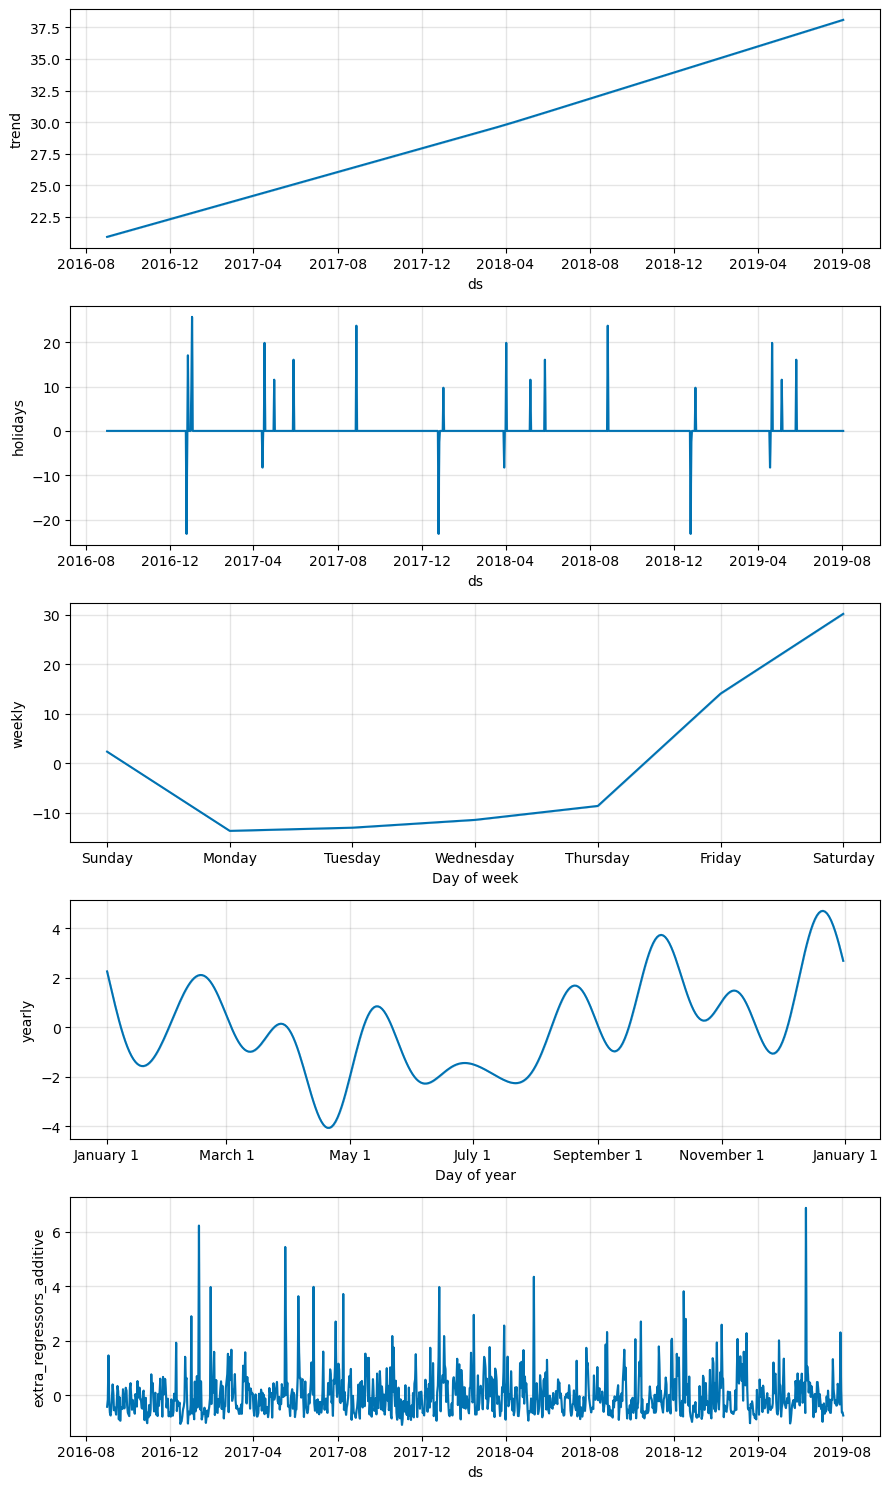

In [273]:
# Generamos una predicción sobre todo el histórico para obtener las componentes
prediccion_total = modelo_corto.predict(df_prophet[["ds"] + regresores_reducido])

# Prophet tiene un método plot_components integrado
fig = modelo_corto.plot_components(prediccion_total)
plt.tight_layout()
plt.show()

## 20. Resumen y próximos pasos

Al finalizar este notebook se han construido y evaluado
empíricamente dos modelos predictivos basados en Prophet, alineados
con los dos escenarios de uso del sistema en producción.

Los pasos realizados han sido:

- Carga del dataset enriquecido y preparación del formato Prophet.
- División inicial en train/test (último trimestre) para
  comparaciones rápidas entre variantes.
- Entrenamiento y evaluación de seis variantes progresivas del modelo:
  base, con festivos, con clima en distintas agregaciones, y con
  conjunto reducido de regresores.
- Análisis de los coeficientes aprendidos en modo MCMC, que reveló
  tres hallazgos: 
  - multicolinealidad entre las variantes 24h y
  ventana de servicio del mismo fenómeno meteorológico
  - baja relevancia de humedad y nubosidad
  - la redundancia estadística de la temperatura. El experimento de diagnóstico confirmó
  empíricamente que el efecto de la temperatura era absorbido por la
  componente de estacionalidad anual del modelo, lo que motivó su
  exclusión del conjunto reducido aplicado al modelo final.
- Replanteamiento del proceso de evaluación tras identificar la
  incoherencia entre el horizonte de validación y el de las
  previsiones meteorológicas disponibles en producción.
- Validación cruzada temporal en dos escenarios operativos:
  corto plazo (14 días, con clima) y medio plazo (30 días, sin clima).
- Entrenamiento de los modelos finales sobre el dataset completo y
  persistencia de ambos en `data/processed/`.
- Inspección visual de las componentes del modelo, que validó la
  coherencia de los patrones aprendidos con el conocimiento del
  dominio.

### Modelos finales

- **Modelo de corto plazo** (`modelo_prophet_corto.pkl`): Prophet con
  festivos y clima reducido (precipitación y viento en
  ventana de servicio). Horizonte recomendado: hasta 14 días.
- **Modelo de medio plazo** (`modelo_prophet_medio.pkl`): Prophet con
  festivos, sin regresores meteorológicos. Horizonte recomendado:
  hasta 30 días.

### Próximos pasos

El siguiente notebook (`04_modelo_sarima.ipynb`) implementará el
modelo SARIMA como referencia comparativa, permitiendo contrastar la
aportación del modelo principal frente a un enfoque estadístico
clásico. Posteriormente se abordará el desarrollo del panel de
visualización (RF08, RF09) que consumirá los modelos persistidos
en este notebook.